<a href="https://colab.research.google.com/github/elhamod/BA305_Fall_2026/blob/main/Session%2003%20-%20Data%20Visualization%20II%20-%20Building%20Charts/lab1_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Lab 1: Visualization in Python**

In this lab you will build charts from raw data, and — just as important — decide
*which* chart tells the truth about that data.

Datasets used:

* `LaptopSalesJanuary2008.csv` — one row per laptop sold by a London computer chain in January 2008
* `WHO.csv` — one row per country, with health and economic indicators

New to Python? Work through the official [Python tutorial](https://docs.python.org/3/tutorial/),
or the shorter Colab version [here](https://colab.research.google.com/drive/18JDPGrc1B4eXQMI3EwsrwTGoC-64H8gi?usp=sharing) (source: Stanford CS231n).

## Setup

We use four libraries throughout the course:

* [numpy](https://numpy.org/) — fast numerical arrays and math functions
* [pandas](https://pandas.pydata.org/) — loading and manipulating tables of data
* [matplotlib](https://matplotlib.org/) — the underlying plotting engine
* [seaborn](https://seaborn.pydata.org/) — a friendlier layer on top of matplotlib, which is what we will mostly write

In [1]:
# Load the libraries we use in this notebook.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

---
# **Example 1: Laptop Sales**

A London computer chain wants to know how its stores compare on price.

In [2]:
# Load the laptop sales data and look at the first few rows.
laptop_df = pd.read_csv('https://raw.githubusercontent.com/AnalyticsArmory/data/main/LaptopSalesJanuary2008.csv')
laptop_df.head()

,Date,Configuration,Customer Postcode,Store Postcode,Retail Price,Screen Size (Inches),Battery Life (Hours),RAM (GB),Processor Speeds (GHz),Integrated Wireless?,HD Size (GB),Bundled Applications?,OS X Customer,OS Y Customer,OS X Store,OS Y Store,CustomerStoreDistance
0,1/1/2008 0:01,163,EC4V 5BH,SE1 2BN,455,15,5,1,2.0,Yes,80,Yes,532041,180995,534057.0,179682.0,2405.873022
1,1/1/2008 0:02,320,SW4 0JL,SW12 9HD,545,15,6,1,2.0,No,300,No,529240,175537,528739.0,173080.0,2507.558574
2,1/1/2008 0:04,23,EC3V 1LR,E2 0RY,515,15,4,1,2.0,Yes,300,Yes,533095,181047,535652.0,182961.0,3194.001409
3,1/1/2008 0:04,169,SW1P 3AU,SE1 2BN,395,15,5,1,2.0,No,40,Yes,529902,179641,534057.0,179682.0,4155.202281
4,1/1/2008 0:06,365,EC4V 4EG,SW1V 4QQ,585,15,6,2,2.0,No,120,Yes,531684,180948,528924.0,178440.0,3729.298057


In [3]:
# Check the size of the table and the type of each column.
laptop_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7956 entries, 0 to 7955
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Date                    7956 non-null   object 
 1   Configuration           7956 non-null   int64  
 2   Customer Postcode       7956 non-null   object 
 3   Store Postcode          7956 non-null   object 
 4   Retail Price            7956 non-null   int64  
 5   Screen Size (Inches)    7956 non-null   int64  
 6   Battery Life (Hours)    7956 non-null   int64  
 7   RAM (GB)                7956 non-null   int64  
 8   Processor Speeds (GHz)  7956 non-null   float64
 9   Integrated Wireless?    7956 non-null   object 
 10  HD Size (GB)            7956 non-null   int64  
 11  Bundled Applications?   7956 non-null   object 
 12  OS X Customer           7956 non-null   int64  
 13  OS Y Customer           7956 non-null   int64  
 14  OS X Store              7952 non-null   

## Pre-processing

The column names contain spaces, which makes them awkward to refer to in code.
Let's rename them.

In [4]:
# Replace the column names with versions that have no spaces.
laptop_df.columns = ("Date", "Configuration", "Customer_Postcode", "Store_Postcode",
                     "Retail_Price", "Screen_Size_Inches", "Battery_Life_Hours",
                     "RAM_GB", "Processor_Speeds_GHz", "Integrated_Wireless",
                     "HD_Size_GB", "Bundled_Applications", "customer_X",
                     "customer_Y", "store_X", "store_Y", "CustomerStoreDistance")
laptop_df.columns

Index(['Date', 'Configuration', 'Customer_Postcode', 'Store_Postcode',
       'Retail_Price', 'Screen_Size_Inches', 'Battery_Life_Hours', 'RAM_GB',
       'Processor_Speeds_GHz', 'Integrated_Wireless', 'HD_Size_GB',
       'Bundled_Applications', 'customer_X', 'customer_Y', 'store_X',
       'store_Y', 'CustomerStoreDistance'],
      dtype='object')

## **Task 1:** compute the average retail price for each store

In [5]:
# Group the rows by store, then average the retail price within each group.
myprices = laptop_df.groupby('Store_Postcode')['Retail_Price'].mean() #.median() .mode()
myprices.round(2)

,Retail_Price
Store_Postcode,
CR7 8LE,488.62
E2 0RY,483.17
E7 8NW,494.38
KT2 5AU,493.90
N17 6QA,494.63
N3 1DH,487.37
NW5 2QH,486.58
S1P 3AU,486.25
SE1 2BN,486.68


## **Task 2:** compare the store averages in a bar chart

Which stores are expensive, and which are cheap?

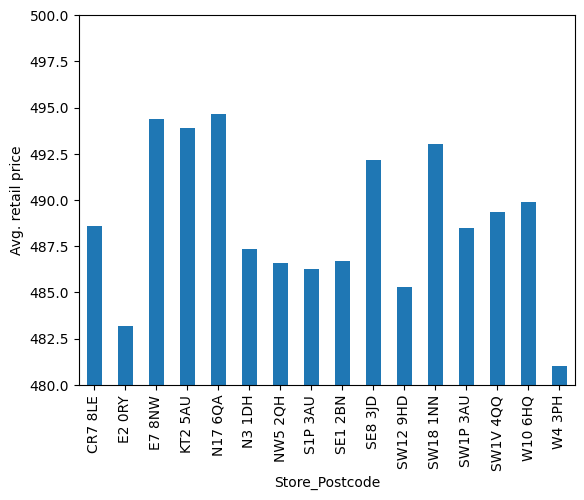

In [6]:
# Bar chart of average price per store, using pandas' built-in plot() function.
ax = myprices.plot(kind='bar')
ax.set_ylabel('Avg. retail price')
ax.set_ylim(480, 500);

**Question 1.** Read the chart above as an executive would. Roughly how much more
expensive is the priciest store than the cheapest one? Would you send someone to
London to investigate the difference?

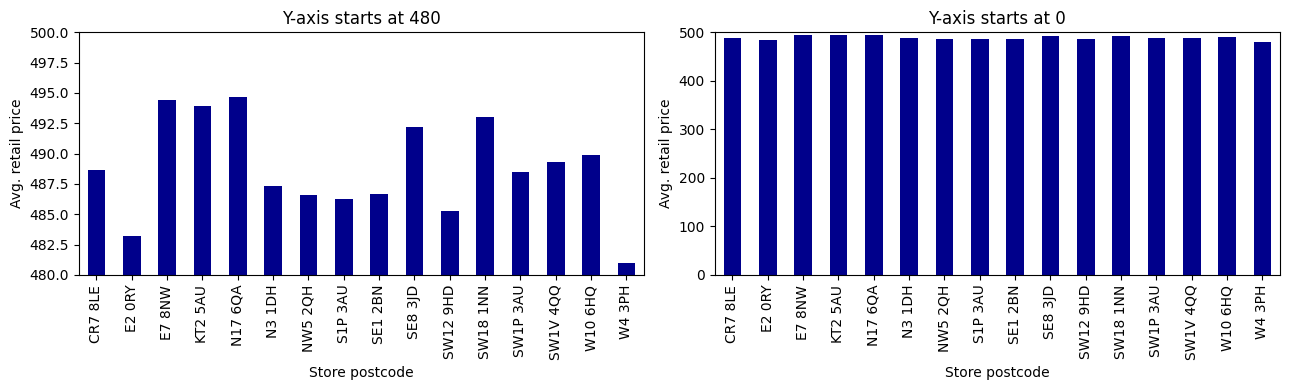

In [7]:
# The same numbers plotted twice: zoomed in, and starting from zero.
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)

myprices.plot(kind='bar', ax=axes[0], color='darkblue')
axes[0].set_ylim(480, 500)
axes[0].set_title('Y-axis starts at 480')
axes[0].set_ylabel('Avg. retail price')
axes[0].set_xlabel('Store postcode')

myprices.plot(kind='bar', ax=axes[1], color='darkblue')
axes[1].set_ylim(0, 500)
axes[1].set_title('Y-axis starts at 0')
axes[1].set_ylabel('Avg. retail price')
axes[1].set_xlabel('Store postcode')

plt.tight_layout()

**Answer**

*Provide your answer here*

shows that the average retail is not as spread apart or different than the original graph


## **Task 3:** look at the full distribution of prices per store, not just the average

An average collapses thousands of sales into one number. A boxplot shows the
spread behind it.

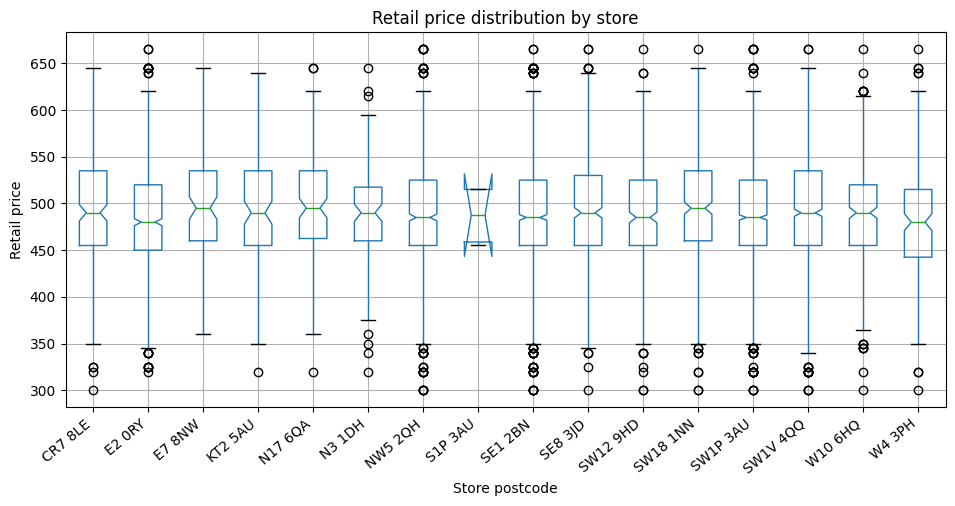

In [10]:
# Boxplot of retail price for each store, showing the spread behind each average.
#ax = laptop_df.boxplot(column='Retail_Price', by='Store_Postcode', figsize=(11, 5))
ax = laptop_df.boxplot(column='Retail_Price', by='Store_Postcode', figsize=(11, 5), notch= True) #notched box plot and will be on exam

ax.set_xlabel('Store postcode')
ax.set_ylabel('Retail price')
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right')
plt.suptitle('')
plt.title('Retail price distribution by store');

**Question 2.** Compare this to the bar chart. What does the boxplot show that the
bar chart could not — and does it change your answer to Question 1?

**Answer**

*Provide your answer here*

similar notches to the median shows possible overlapping in prices. while ones that are not touching or shows even a little similarity, shows less chance of overlapping

---
# **Example 2: World Health Organization (WHO) Data**

One row per country, with economic and health indicators.

In [11]:
# Load the WHO country data and look at the first few rows.
who_df = pd.read_csv('https://raw.githubusercontent.com/AnalyticsArmory/data/main/WHO.csv')
who_df.head()

,Country,Region,Population,Under15,Over60,FertilityRate,LifeExpectancy,ChildMortality,CellularSubscribers,LiteracyRate,GNI,PrimarySchoolEnrollmentMale,PrimarySchoolEnrollmentFemale
0,Afghanistan,Eastern Mediterranean,29825,47.42,3.82,5.40,60,98.5,54.26,NaN,1140.0,NaN,NaN
1,Albania,Europe,3162,21.33,14.93,1.75,74,16.7,96.39,NaN,8820.0,NaN,NaN
2,Algeria,Africa,38482,27.42,7.17,2.83,73,20.0,98.99,NaN,8310.0,98.2,96.4
3,Andorra,Europe,78,15.20,22.86,NaN,82,3.2,75.49,NaN,NaN,78.4,79.4
4,Angola,Africa,20821,47.58,3.84,6.10,51,163.5,48.38,70.1,5230.0,93.1,78.2


In [12]:
# Check the size of the table and the type of each column.
who_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 194 entries, 0 to 193
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        194 non-null    object 
 1   Region                         194 non-null    object 
 2   Population                     194 non-null    int64  
 3   Under15                        194 non-null    float64
 4   Over60                         194 non-null    float64
 5   FertilityRate                  183 non-null    float64
 6   LifeExpectancy                 194 non-null    int64  
 7   ChildMortality                 194 non-null    float64
 8   CellularSubscribers            184 non-null    float64
 9   LiteracyRate                   103 non-null    float64
 10  GNI                            162 non-null    float64
 11  PrimarySchoolEnrollmentMale    101 non-null    float64
 12  PrimarySchoolEnrollmentFemale  101 non-null    flo

## **Task 1:** what is the relationship between fertility rate and national income (GNI)?

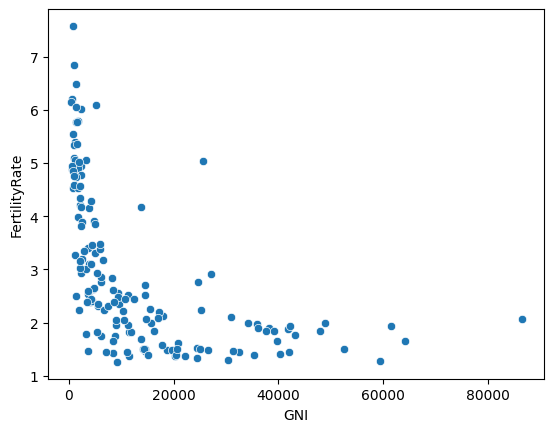

In [13]:
# Scatterplot: one dot per country, income on the x-axis and fertility on the y-axis.
sns.scatterplot(data=who_df, x='GNI', y='FertilityRate');

**Question 3.** Describe the shape of the scatter above in one sentence.
Then read that sentence back: does anything in it claim that income *causes* the
change in fertility?


**Answer**

*Provide your answer here*


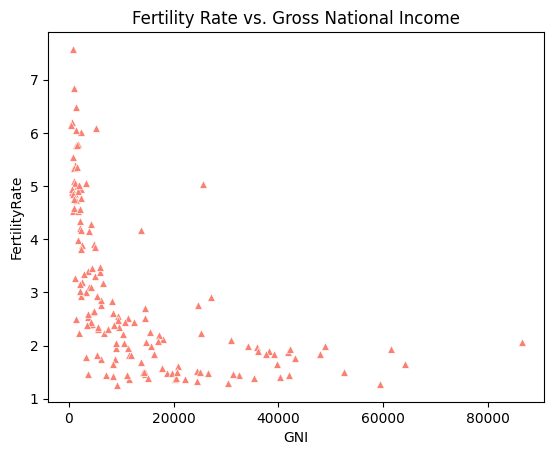

In [14]:
# Restyle the same chart: change the marker, color, size, and add a title.
ax = sns.scatterplot(data=who_df, x='GNI', y='FertilityRate',
                     marker='^', color='salmon', s=30)
ax.set_title('Fertility Rate vs. Gross National Income');

In [15]:
# Save the figure to a file so it can be dropped into a slide deck or report.
ax.figure.savefig('fig_fert_vs_gni.png', dpi=300, bbox_inches='tight')

## **Task 2:** the same data as a line chart

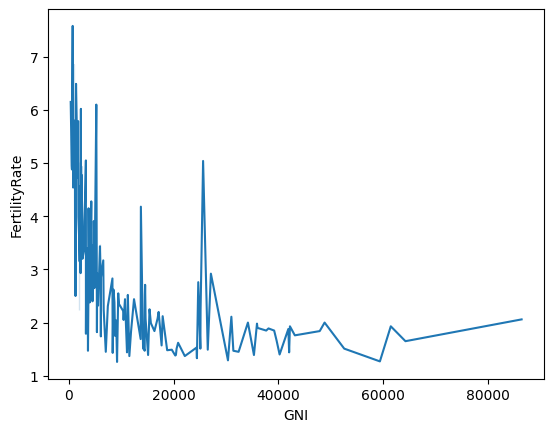

In [16]:
# Plot the identical data with lineplot() instead of scatterplot().
sns.lineplot(data=who_df, x='GNI', y='FertilityRate');

**Question 4.** This ran without an error and produced a chart. Why is it still the
wrong chart?

**Answer**

*Provide your answer here*


## **Task 3:** add a third variable — first "Region", then "LifeExpectancy"

In [ ]:
# Color each country by its region (a categorical variable).
sns.scatterplot(data=who_df, x='GNI', y='FertilityRate', hue='Region');

In [ ]:
# Color each country by life expectancy (a numeric variable) instead.
sns.scatterplot(data=who_df, x='GNI', y='FertilityRate', hue='LifeExpectancy');

**Note on color.** Seaborn switched palettes automatically, and it was right to.
Categories (regions) have no order, so they need distinct, unrelated hues. A numeric
variable (life expectancy) *is* ordered, so it needs a single hue that varies in
lightness — that way the reader can see "more" and "less" at a glance. Using a
rainbow palette for a numeric variable destroys that. See this
[palette guide](https://medium.com/@morganjonesartist/color-guide-to-seaborn-palettes-da849406d44f).


**Question 5.** Look at the two charts above together. What does a country's
life expectancy tend to do as fertility falls and income rises — and what is the one
word you must not use when you say it?


**Answer**

*Provide your answer here*


## **Task 4:** is fertility rate a good predictor of the share of population under 15?

In [ ]:
# Scatterplot of fertility rate against the percentage of the population under 15.
sns.scatterplot(data=who_df, x='FertilityRate', y='Under15');

**Question 6.** Is fertility rate a good predictor of the share of the population
under 15? Say what the shape of the scatter tells you, and what about that shape would
bother a method that assumes a straight line.


**Answer**

*Provide your answer here*


In [ ]:
# Approach 1: keep the data as-is and stretch the x-axis onto a log scale.
splot = sns.scatterplot(data=who_df, x='FertilityRate', y='Under15')
splot.set(xscale='log');

In [ ]:
# Approach 2: create a new column holding the log of fertility rate, and plot that.
who_df['logFertilityRate'] = np.log(who_df['FertilityRate'])
sns.scatterplot(data=who_df, x='logFertilityRate', y='Under15');

**Question 7.** The two charts above have the same shape. What is actually different
between them, and why would you choose one over the other?

**Answer**

*Provide your answer here*


In [ ]:
# Fit and draw a straight line through the transformed data, with a 95% confidence band.
sns.regplot(data=who_df, x='logFertilityRate', y='Under15');

The shaded band is the 95% confidence interval for the fitted line — the range in
which the true line plausibly falls, given this sample. It is narrow in the middle,
where most of the data sits, and flares at the edges, where there is little data to
pin it down. Sparse data means an uncertain line, and the chart says so.

---
# **Follow up Questions and Exercises**

**Exercise 1.** Your manager has seen the bar chart from Task 2 and sends you a note:

> *"The W4 3PH store is underpricing us. Find out what's going on at that location."*

Investigate. Then produce **one chart** that shows what actually explains the
variation in laptop prices, and be ready to defend both your conclusion and your
choice of chart.

Useful columns: `HD_Size_GB`, `RAM_GB`, `Battery_Life_Hours`, `Processor_Speeds_GHz`,
`Integrated_Wireless`, `Screen_Size_Inches`.

No starter code — deciding what to plot is the exercise.

In [ ]:
# Your code here


**Answer**

*Provide your answer here*
